# Data preparation

Please clone [this repo](https://github.com/emerald-geomodelling/simpeg-simpleem-examples) next to this one and run the notebook
[demo_data_download.ipynb](https://github.com/emerald-geomodelling/simpeg-simpleem-examples/blob/master/measured_inversion.ipynb)
before this notebook to download the demo data to data/IncisedValley.

In [35]:
import libaarhusxyz
import beryl_pipeline.file_import
import beryl_pipeline.processing
import beryl_pipeline.inversion
import luigi.contrib.opener
import poltergust_luigi_utils.caching
import yaml
import shutil
import os.path

In [36]:
rootpath = os.path.abspath("./data")
cachepath = os.path.expanduser("~/.cache/poltergust-luigi-utils")
srcpath = os.path.abspath("../../simpeg-simpleem-examples/Data_Brazil/SourceData")

src = "file://" + srcpath
root = "file://" + rootpath

In [37]:
if os.path.exists(rootpath):
    shutil.rmtree(rootpath)
if os.path.exists(cachepath):
    shutil.rmtree(cachepath)

In [38]:
with poltergust_luigi_utils.caching.CachingOpenerTarget(root + "/import/config.yml").open("w") as f:
    yaml.dump({
        "importer": {
            "name": "SkyTEM XYZ",
            "args": {
                "projection": 25832,
                "files": {
                    "xyzfile": src + "/Demo.xyz",
                    "gexfile": src + "/Demo.gex"
                }
            }
        }
    }, f)

In [39]:
import_task = beryl_pipeline.file_import.Import(import_name = root + "/import")

luigi.build([import_task], local_scheduler=True)

DEBUG: Checking if Import(import_name=file:///Users/guroskurdal/Notebooks/emerald-beryl-pipeline/docs/data/import) is complete
INFO: Informed scheduler that task   Import_file____Users_gu_b967995d94   has status   PENDING
INFO: Done scheduling tasks
INFO: Running Worker with 1 processes
DEBUG: Asking scheduler for work...
DEBUG: Pending tasks: 1
INFO: [pid 51296] Worker Worker(salt=6936053409, workers=1, host=MacBookPro.home, username=guroskurdal, pid=51296) running   Import(import_name=file:///Users/guroskurdal/Notebooks/emerald-beryl-pipeline/docs/data/import)


header [General] parsed
header [Channel1] parsed
header [Channel2] parsed


/Users/guroskurdal/venv/20250616BerylTest/lib/python3.10/site-packages/libaarhusxyz/xyz.py:590: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.flightlines.groupby(self.line_id_column).apply(lambda a: a.describe().T),
/Users/guroskurdal/venv/20250616BerylTest/lib/python3.10/site-packages/libaarhusxyz/xyz.py:590: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.flightlines.groupby(self.line_id_column).apply(lambd

True

In [40]:
os.listdir(rootpath + "/import")

['log.yml',
 'out.300101.gex',
 'out.300201.geojson',
 'out.geojson',
 'out.300201.summary.yml',
 'out.300201.msgpack',
 'out.msgpack',
 'out.300201.gex',
 'out.xyz',
 'out.300101.summary.yml',
 'out.300101.xyz',
 'out.300101.geojson',
 'out.300101.msgpack',
 'DONE',
 'out.summary.yml',
 'config.yml',
 'out.300201.xyz',
 'out.gex']

In [41]:
with poltergust_luigi_utils.caching.CachingOpenerTarget(root + "/processing/config.yml").open("w") as f:
     f.write(f"""
data:
  args:
    data: {root}/import/out.xyz
    sidecar: null
    system_data: {root}/import/out.gex
  name: emeraldprocessing.pipeline.ProcessingData
steps:
- Enable/Disable gates by index:
    action: disable
    channel_and_gate:
      channel: 1
      gate: 0
- Enable/Disable gates by index:
    action: disable
    channel_and_gate:
      channel: 2
      gate: 0
- Disable gates by STD values:
    channel_and_gate:
      channel: 1
      gate: 7
    disable_earlier_gates: 0
    disable_sounding_tails: true
    std_threshold: 0.15
- Disable gates by STD values:
    channel_and_gate:
      channel: 2
      gate: 13
    disable_earlier_gates: 0
    disable_sounding_tails: true
    std_threshold: 0.15
- Disable gates by negative data:
    channel_and_gate:
      channel: 1
      gate: 7
    disable_earlier_gates: 0
    disable_sounding_tails: true
    save_filter_to_layer_data: true
- Disable gates by negative data:
    channel_and_gate:
      channel: 2
      gate: 13
    disable_earlier_gates: 0
    disable_sounding_tails: true
- Disable gates by slope max:
    channel_and_gate:
      channel: 1
      gate: 7
    disable_earlier_gates: 0
    disable_sounding_tails: true
    max_slope: 0
    verbose: true
- Disable gates by slope max:
    channel_and_gate:
      channel: 2
      gate: 13
    disable_earlier_gates: 0
    disable_sounding_tails: true
    max_slope: 0
    verbose: true
- Disable gates by slope min:
    channel_and_gate:
      channel: 1
      gate: 7
    disable_earlier_gates: 0
    disable_sounding_tails: true
    min_slope: -6.0
    verbose: true
- Disable gates by slope min:
    channel_and_gate:
      channel: 2
      gate: 13
    disable_earlier_gates: 0
    disable_sounding_tails: true
    min_slope: -6.0
    verbose: true
- Disable soundings by number of active gates:
    channel: 1
    min_number_of_gates: 4
- Disable soundings by number of active gates:
    channel: 2
    min_number_of_gates: 4
""")


In [42]:
processing_task = beryl_pipeline.processing.Processing(processing_name = root + "/processing")

luigi.build([processing_task], local_scheduler=True)


DEBUG: Checking if Processing(processing_name=file:///Users/guroskurdal/Notebooks/emerald-beryl-pipeline/docs/data/processing) is complete
DEBUG: Checking if Import(import_name=file:///Users/guroskurdal/Notebooks/emerald-beryl-pipeline/docs/data/import) is complete
INFO: Informed scheduler that task   Processing_file____Users_gu_76769ddc2e   has status   PENDING
INFO: Informed scheduler that task   Import_file____Users_gu_b967995d94   has status   DONE
INFO: Done scheduling tasks
INFO: Running Worker with 1 processes
DEBUG: Asking scheduler for work...
DEBUG: Pending tasks: 1
INFO: [pid 51296] Worker Worker(salt=1586876522, workers=1, host=MacBookPro.home, username=guroskurdal, pid=51296) running   Processing(processing_name=file:///Users/guroskurdal/Notebooks/emerald-beryl-pipeline/docs/data/processing)


=============== Reading SkyTEM xyz data ===============
  - Reading gex file.
header [General] parsed
header [Channel1] parsed
header [Channel2] parsed
  - Reading xyz file.
  - building xyz dictionary
  - Done reading the data package!
  - Time used to read and import the data package: 0.3573479652404785 sec.


=============== Processing step 1 ===============
  - Step name: 'Enable/Disable gates by index'
  - Disabling gate-0 from channel-1
  - 3.57 % of the data have been disabled by this filter
  - Time used to disable timegate-0 from Channel1: 0.007470130920410156 sec.


=============== Processing step 2 ===============
  - Step name: 'Enable/Disable gates by index'
  - Disabling gate-0 from channel-2
  - 3.12 % of the data have been disabled by this filter
  - Time used to disable timegate-0 from Channel2: 0.0015239715576171875 sec.


=============== Processing step 3 ===============
  - Step name: 'Disable gates by STD values'
  - Disabling channel-1 after gate-7 based on 0.15 S

/Users/guroskurdal/venv/20250616BerylTest/lib/python3.10/site-packages/libaarhusxyz/xyz.py:590: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.flightlines.groupby(self.line_id_column).apply(lambda a: a.describe().T),
/Users/guroskurdal/venv/20250616BerylTest/lib/python3.10/site-packages/libaarhusxyz/xyz.py:590: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.flightlines.groupby(self.line_id_column).apply(lambd

True

In [43]:
os.listdir(rootpath + "/processing")


['log.yml',
 'processed.300101.gex',
 'processed.300201.diff.msgpack',
 'processed.summary.yml',
 'processed.gex',
 'processed.300101.diff.msgpack',
 'processed.300201.gex',
 'processed.300201.geojson',
 'processed.300201.msgpack',
 'processed.diff.msgpack',
 'DONE',
 'processed.300101.geojson',
 'processed.300101.xyz',
 'config.yml',
 'processed.300101.msgpack',
 'processed.300101.summary.yml',
 'processed.msgpack',
 'processed.geojson',
 'processed.300201.summary.yml',
 'processed.xyz',
 'processed.300201.xyz']

In [44]:
with luigi.contrib.opener.OpenerTarget(root + "/inversion/config.yml").open("w") as f:
     f.write(f"""
data: {root}/processing/processed.xyz
system_data: {root}/processing/processed.gex
system:
  name: Dual moment TEM
  args:
    validate: true
    optimizer:
      max_iter: 40
      max_iter_cg: 20
    directives:
      beta:
        seed: 0
        beta0_ratio: 10
        cooling_rate: 1
        cooling_factor: 2
      irls:
        enable: false
        minGNiter: 1
        coolingRate: 1
        fix_Jmatrix: true
        f_min_change: 0.001
        max_iterations: 30
    simulation:
      n_cpu: 3
      solver: LU
      parallel: true
    startmodel:
      res: 100
      n_layer: 30
      thicknesses_type: logspaced
      top_depth_last_layer: 400
      thicknesses_minimum_dz: 1
      thicknesses_geomtric_factor: 1.15309
    gate_filter:
      end_hm: 30
      end_lm: 26
      start_hm: 12
      start_lm: 5
    uncertainties:
      std_data: 0.03
      noise_exponent: -0.5
      noise_level_1ms: 1.e-9
      std_data_override: false
    regularization:
      alpha_r: 1
      alpha_s: 0.0001
      alpha_z: 1
    rx_orientation: z
    tx_orientation: z
    save_iterations: false
""")
 

In [45]:
inversion_task = beryl_pipeline.inversion.Inversion(inversion_name = root + "/inversion")

luigi.build([inversion_task], local_scheduler=True)

DEBUG: Checking if Inversion(inversion_name=file:///Users/guroskurdal/Notebooks/emerald-beryl-pipeline/docs/data/inversion) is complete
DEBUG: Checking if Processing(processing_name=file:///Users/guroskurdal/Notebooks/emerald-beryl-pipeline/docs/data/processing) is complete
INFO: Informed scheduler that task   Inversion_file____Users_gu_4e8f8ffd44   has status   PENDING
INFO: Informed scheduler that task   Processing_file____Users_gu_76769ddc2e   has status   DONE
INFO: Done scheduling tasks
INFO: Running Worker with 1 processes
DEBUG: Asking scheduler for work...
DEBUG: Pending tasks: 1
INFO: [pid 51296] Worker Worker(salt=7228098463, workers=1, host=MacBookPro.home, username=guroskurdal, pid=51296) running   Inversion(inversion_name=file:///Users/guroskurdal/Notebooks/emerald-beryl-pipeline/docs/data/inversion)


header [General] parsed
header [Channel1] parsed
header [Channel2] parsed
Monitoring already in progress.
Using default (spLU) solver


ERROR: [pid 51296] Worker Worker(salt=7228098463, workers=1, host=MacBookPro.home, username=guroskurdal, pid=51296) failed    Inversion(inversion_name=file:///Users/guroskurdal/Notebooks/emerald-beryl-pipeline/docs/data/inversion)
Traceback (most recent call last):
  File "/Users/guroskurdal/venv/20250616BerylTest/lib/python3.10/site-packages/luigi/worker.py", line 210, in run
    new_deps = self._run_get_new_deps()
  File "/Users/guroskurdal/venv/20250616BerylTest/lib/python3.10/site-packages/luigi/worker.py", line 138, in _run_get_new_deps
    task_gen = self.task.run()
  File "/Users/guroskurdal/venv/20250616BerylTest/lib/python3.10/site-packages/beryl_pipeline/inversion.py", line 184, in run
    self.invert()
  File "/Users/guroskurdal/venv/20250616BerylTest/lib/python3.10/site-packages/beryl_pipeline/inversion.py", line 122, in invert
    self.inversion.invert()
  File "/Users/guroskurdal/venv/20250616BerylTest/lib/python3.10/site-packages/SimPEG/electromagnetics/utils/static_inst

False

In [17]:
os.listdir(rootpath + "/inversion")


['log.yml',
 'smooth_synthetic.100101_0.summary.yml',
 'smooth_synthetic.100101_0.geojson',
 'smooth_synthetic.100101_0.msgpack',
 'smooth_synthetic.xyz',
 'processed.summary.yml',
 'monitor_info.csv',
 'smooth_model.100101_0.xyz',
 'smooth_model.summary.yml',
 'processed.100101_0.xyz',
 'smooth_synthetic.geojson',
 'smooth_model.100101_0.summary.yml',
 'smooth_synthetic.msgpack',
 'DONE',
 'processed.100101_0.summary.yml',
 'config.yml',
 'smooth_model.msgpack',
 'smooth_model.xyz',
 'smooth_synthetic.100101_0.xyz',
 'smooth_synthetic.summary.yml',
 'smooth_model.geojson',
 'smooth_model.100101_0.geojson',
 'processed.msgpack',
 'processed.100101_0.geojson',
 'processed.geojson',
 'processed.100101_0.msgpack',
 'processed.xyz',
 'smooth_model.100101_0.msgpack']

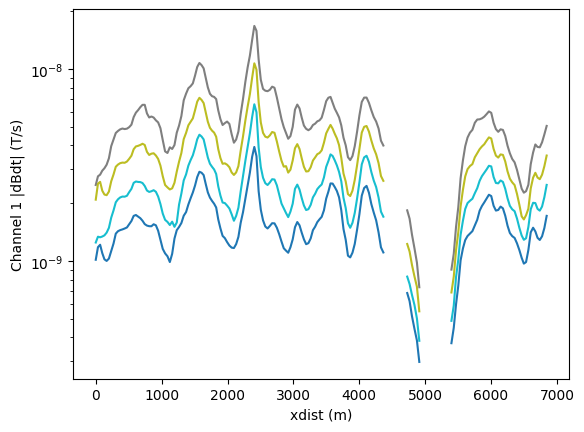

In [18]:
libaarhusxyz.XYZ(rootpath + "/inversion/processed.xyz", normalize=True).plot()

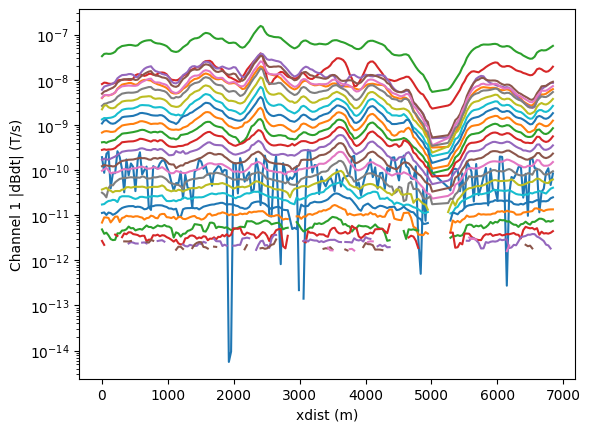

In [19]:
libaarhusxyz.XYZ(rootpath + "/processing/processed.xyz", normalize=True).plot()

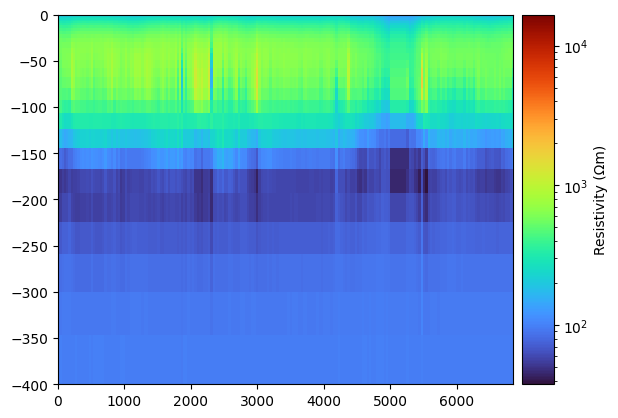

In [20]:
libaarhusxyz.XYZ(rootpath + "/inversion/smooth_model.xyz").plot()

In [17]:
libaarhusxyz.XYZ(rootpath + "/inversion/sparse_model.xyz").plot()

FileNotFoundError: [Errno 2] No such file or directory: '/home/redhog/Projects/Emerald/emerald-beryl-pipeline/docs/data/inversion/sparse_model.xyz'